# INP浓度的时间序列

### 区分显著/不显著数据点

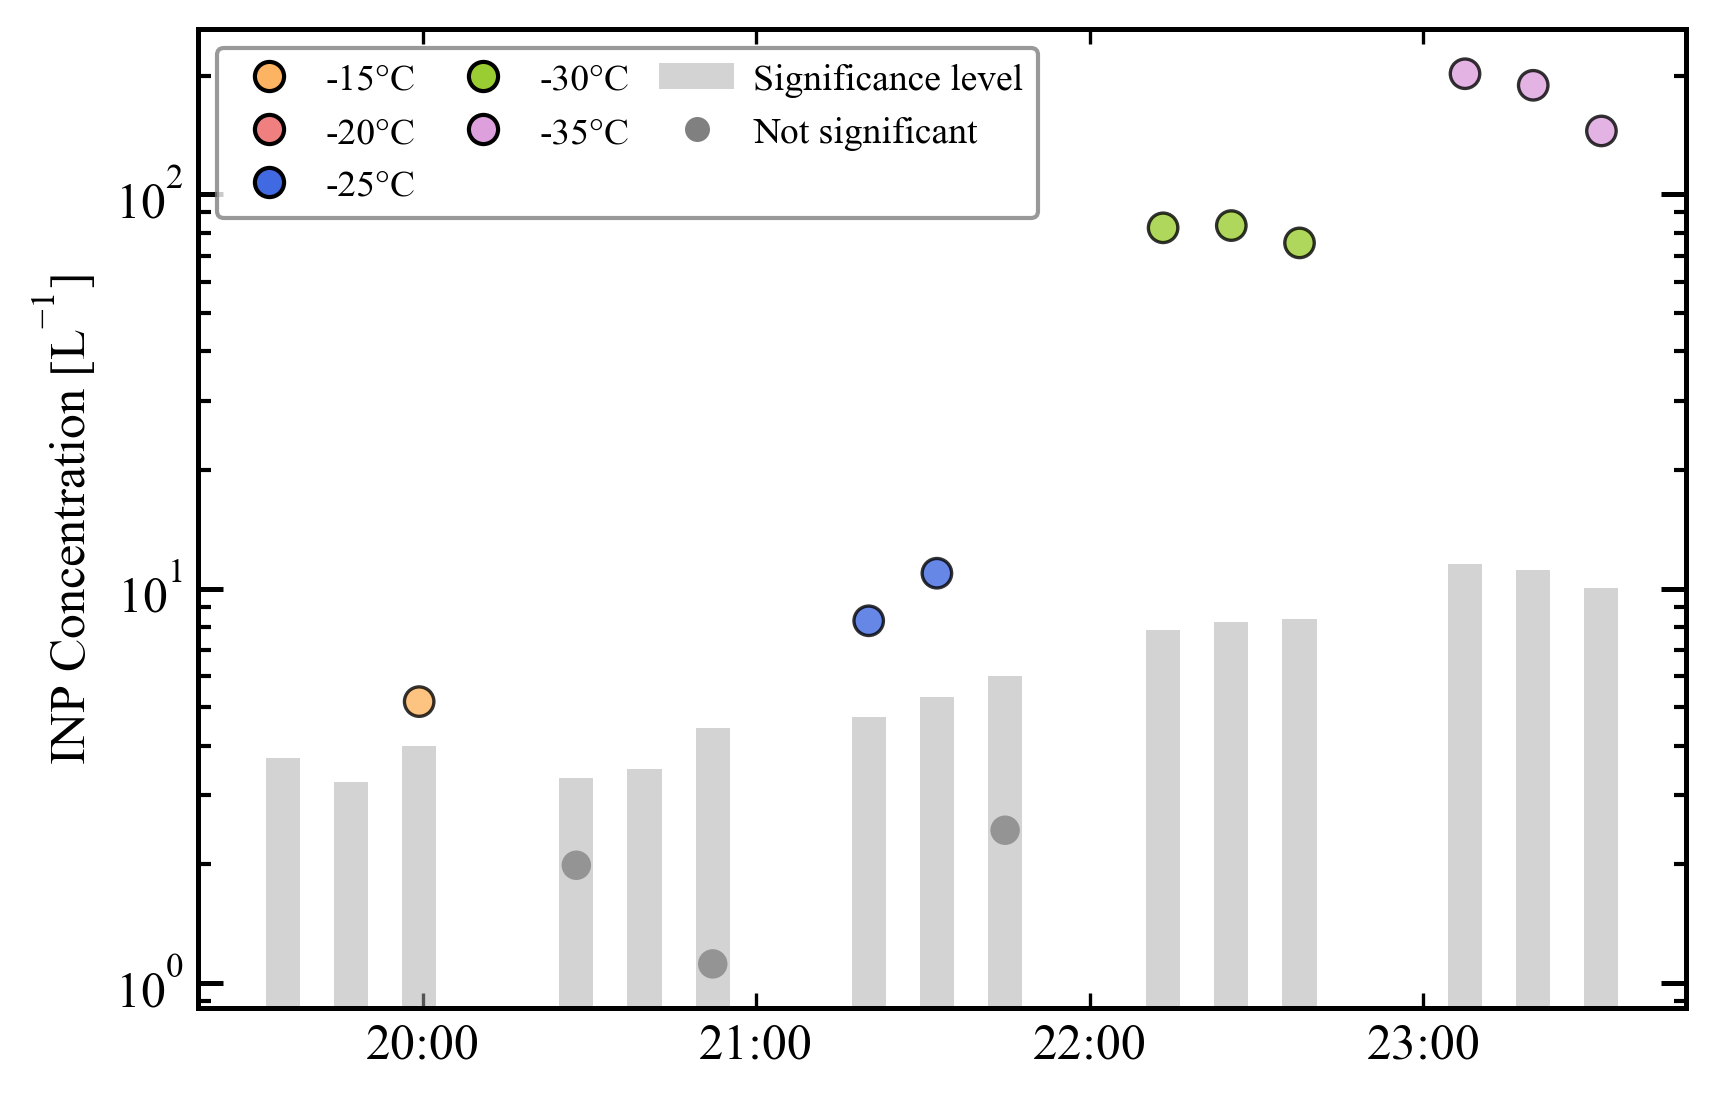

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ==========================================
# 0. 全局学术图表格式设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
plt.rcParams['mathtext.fontset'] = 'custom'

# ==========================================
# 1. 读取数据
# ==========================================
df = pd.read_csv(r"D:\Coding\Data\CFDC_train_video\processed\N_INP.csv")

temps = [-15, -20, -25, -30, -35]
df['Time'] = pd.to_datetime(df['Time'])

# ==========================================
# 2. 准备绘图参数
# ==========================================
colors = {
    -15: '#FDB462', -20: '#F08080', -25: '#4169E1', 
    -30: '#9ACD32', -35: '#DDA0DD'
}
#
fig, ax = plt.subplots(1, 1, dpi=300)

# 提取并排序
df_sig = df[df['Is_Significant'] == True].sort_values('Time').copy()
df_nonsig = df[df['Is_Significant'] == False].sort_values('Time').copy()

# --- A. 绘制置信区间---
dt_mode = df['Time'].diff().value_counts().index[0]
bar_width = (dt_mode.total_seconds() / 86400) * 0.5
ax.bar(df['Time'], height=df['Significance_Level(#/L)'], 
        width=bar_width, color='#A9A9A9', alpha=0.5, edgecolor='none', zorder=2)
    
# --- B. 绘制原始散点 ---
ax.scatter(df_nonsig['Time'], df_nonsig['N_INP(#/L)'], 
            s=50, alpha=1, c='gray', edgecolor='none', zorder=0)
ax.scatter(df_sig['Time'], df_sig['N_INP(#/L)'], c = df_sig['T_a(degC)'].map(colors),
            s=50, alpha=0.8, edgecolor='black', linewidth=0.8, zorder=1)


# --- C. Y轴设置 ---
ax.set_yscale('log')

ax.tick_params(axis='y', which='major', length=6, width=1.2, direction='in', left=True, right=True)
ax.tick_params(axis='y', which='minor', length=3, width=1, direction='in', left=True, right=True)

# --- D. 绘制图例 ---
# 将颜色映射关系转换为图例元素
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[temp], markeredgecolor='black', markersize=7, label=f'{temp}°C') for temp in temps
    ] + [
        Patch(facecolor='#A9A9A9', alpha=0.5, edgecolor='none', label='Significance level'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=7, label='Not significant')
    ]
    
ax.legend(handles=legend_elements, loc='upper left', ncol=3, frameon=True, 
        edgecolor='gray', fontsize=9, handletextpad=0.5, columnspacing=0.8)

# ==========================================
# 4. 整体格式调整
# ==========================================
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate(rotation=0, ha='center') # 防止X轴日期过长重叠，如果重叠可以把 rotation 改为 30

ax.set_ylabel('INP Concentration [L$^{-1}$]')

plt.show()